# 1. Dataset Understanding

In [1]:
import pandas as pd
import numpy as np     
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler , PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv('AmesHousing - AmesHousing.csv')

In [4]:

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


# 2. EDA

## 2.1 Data Quality Check (Missing Values Report)

In [5]:
df.isnull().sum()


Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      490
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 82, dtype: int64

## 2.2 Target Variable Analysis (SalePrice)

SalePrice stats:
  Mean:     180,796   Skewness: 1.743
  Median:   160,000   Kurtosis: 5.108

log1p(SalePrice) stats:
  Skewness: -0.015   Kurtosis: 1.509


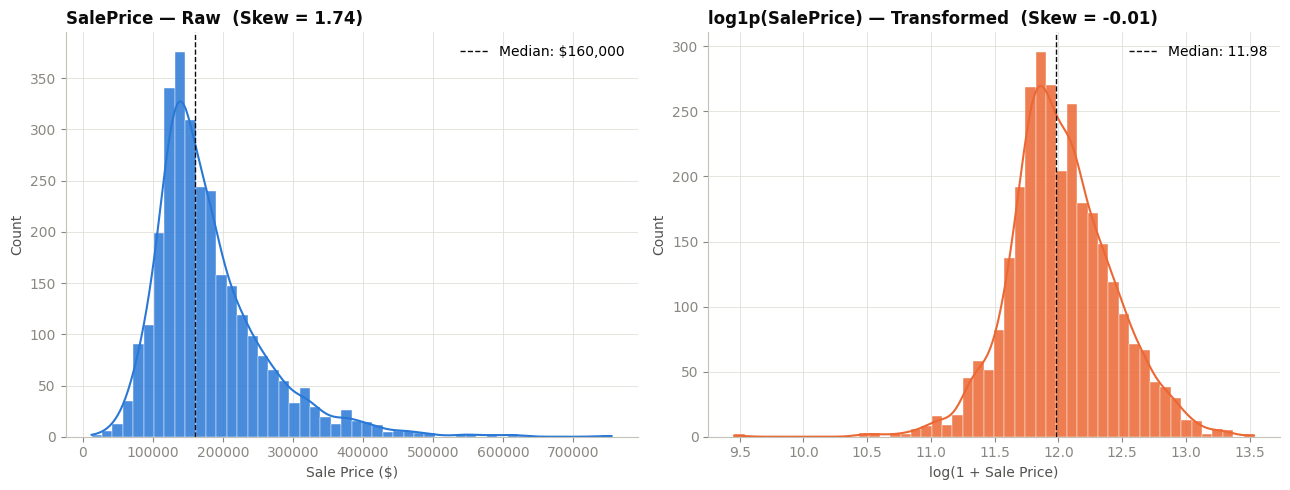

In [6]:
from scipy.stats import skew, kurtosis
from scipy import stats

# --- Raw SalePrice stats ---
sp = df['SalePrice']
log_sp = np.log1p(sp)

print("SalePrice stats:")
print(f"  Mean:     {sp.mean():,.0f}   Skewness: {skew(sp):.3f}")
print(f"  Median:   {sp.median():,.0f}   Kurtosis: {kurtosis(sp):.3f}")
print(f"\nlog1p(SalePrice) stats:")
print(f"  Skewness: {skew(log_sp):.3f}   Kurtosis: {kurtosis(log_sp):.3f}")

# --- Clean, styled visualization ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': '#52514e',
    'xtick.color': '#898781',
    'ytick.color': '#898781',
    'axes.grid': True,
    'grid.color': '#e1e0d9',
    'grid.linewidth': 0.6,
    'axes.axisbelow': True,
})

BLUE, ORANGE = '#2a78d6', '#eb6834'

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw distribution
sns.histplot(sp, bins=50, kde=True, color=BLUE, ax=axes[0],
             edgecolor='white', linewidth=0.3, alpha=0.85)
axes[0].axvline(sp.median(), color='#0b0b0b', linestyle='--', linewidth=1,
                label=f'Median: ${sp.median():,.0f}')
axes[0].set_title(f'SalePrice — Raw  (Skew = {skew(sp):.2f})',
                   fontsize=12, color='#0b0b0b', fontweight='bold', loc='left')
axes[0].set_xlabel('Sale Price ($)')
axes[0].legend(frameon=False)
for spine in ['top', 'right']:
    axes[0].spines[spine].set_visible(False)

# Log-transformed distribution
sns.histplot(log_sp, bins=50, kde=True, color=ORANGE, ax=axes[1],
             edgecolor='white', linewidth=0.3, alpha=0.85)
axes[1].axvline(log_sp.median(), color='#0b0b0b', linestyle='--', linewidth=1,
                label=f'Median: {log_sp.median():.2f}')
axes[1].set_title(f'log1p(SalePrice) — Transformed  (Skew = {skew(log_sp):.2f})',
                   fontsize=12, color='#0b0b0b', fontweight='bold', loc='left')
axes[1].set_xlabel('log(1 + Sale Price)')
axes[1].legend(frameon=False)
for spine in ['top', 'right']:
    axes[1].spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

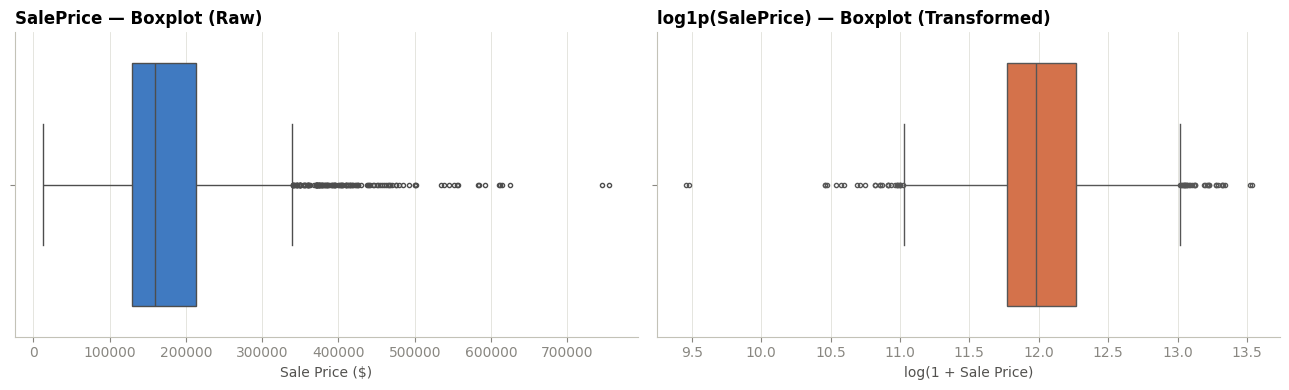

IQR bounds: [3,500, 339,500]
Number of SalePrice outliers (raw): 137 (4.7%)


In [7]:
# --- Box plot: SalePrice outliers ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(x=sp, color=BLUE, ax=axes[0], fliersize=3, linewidth=1)
axes[0].set_title('SalePrice — Boxplot (Raw)', fontsize=12, fontweight='bold', loc='left')
axes[0].set_xlabel('Sale Price ($)')

sns.boxplot(x=log_sp, color=ORANGE, ax=axes[1], fliersize=3, linewidth=1)
axes[1].set_title('log1p(SalePrice) — Boxplot (Transformed)', fontsize=12, fontweight='bold', loc='left')
axes[1].set_xlabel('log(1 + Sale Price)')

for ax in axes:
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

# --- Quantify outliers using the IQR method ---
Q1, Q3 = sp.quantile(0.25), sp.quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outliers = sp[(sp < lower) | (sp > upper)]
print(f"IQR bounds: [{lower:,.0f}, {upper:,.0f}]")
print(f"Number of SalePrice outliers (raw): {len(outliers)} ({len(outliers)/len(sp)*100:.1f}%)")

## 2.3 Numerical Feature Analysis (Outlier Scan)

Checking 36 numerical features for outliers


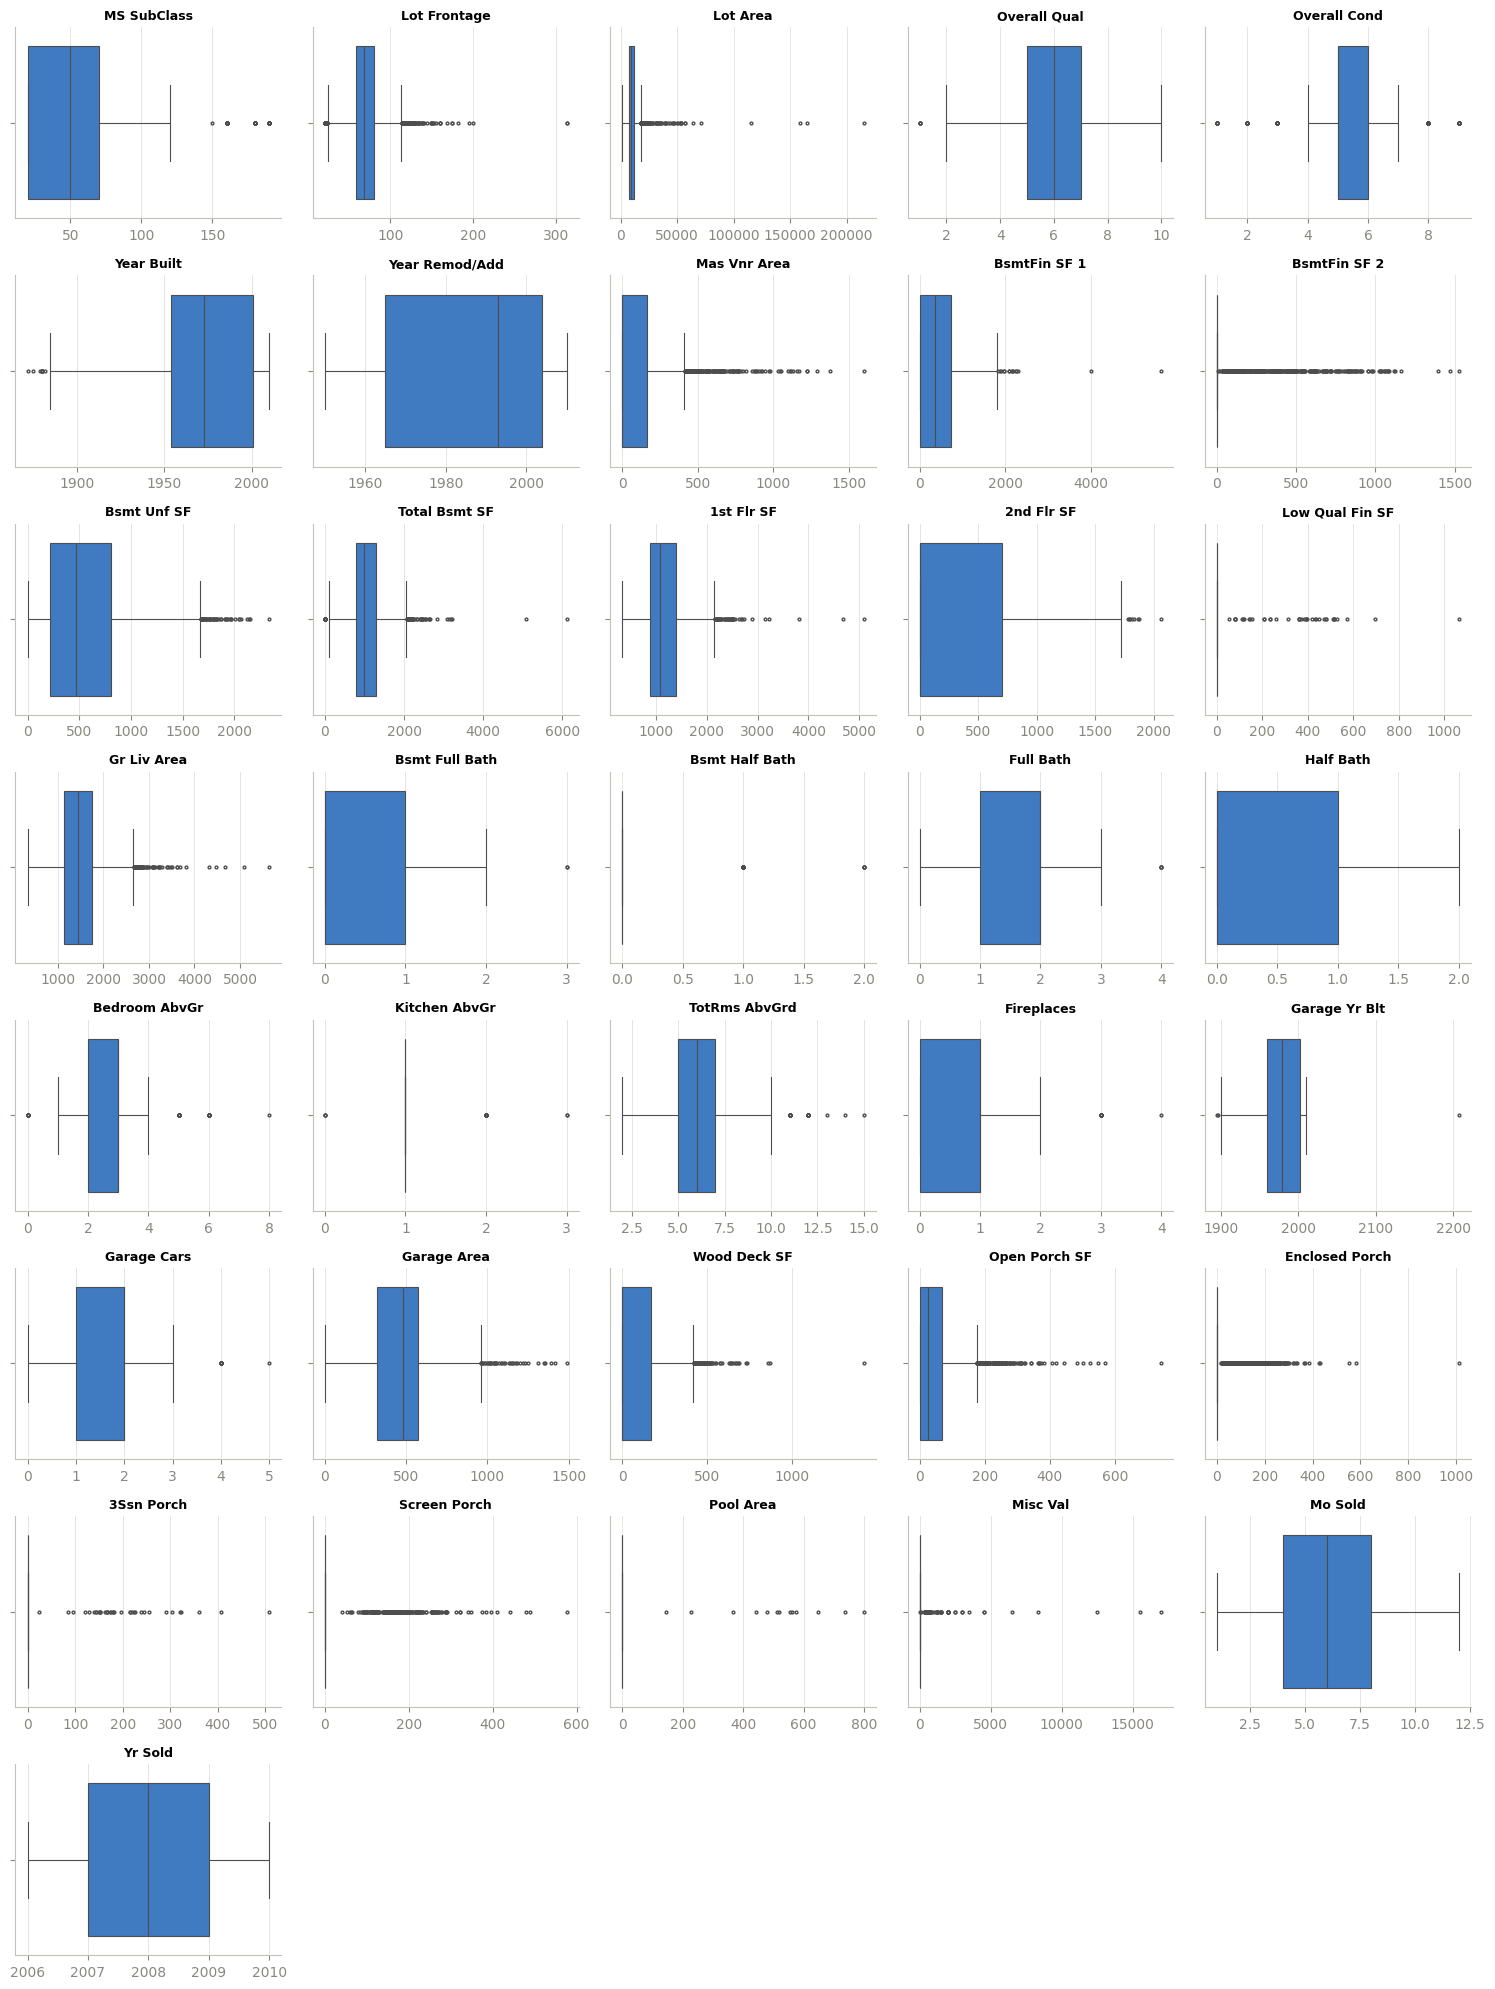

In [8]:
# --- Boxplots for ALL numerical features (outlier scan) ---

# Exclude ID columns (not real features) and SalePrice (already checked separately)
exclude_cols = ['Order', 'PID', 'SalePrice']
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

print(f"Checking {len(numeric_cols)} numerical features for outliers")

n_cols = 5
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*2.5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i], color=BLUE, fliersize=2, linewidth=0.8)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('')
    for spine in ['top', 'right']:
        axes[i].spines[spine].set_visible(False)

# hide unused subplot slots
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 2.4 Categorical Feature Analysis 

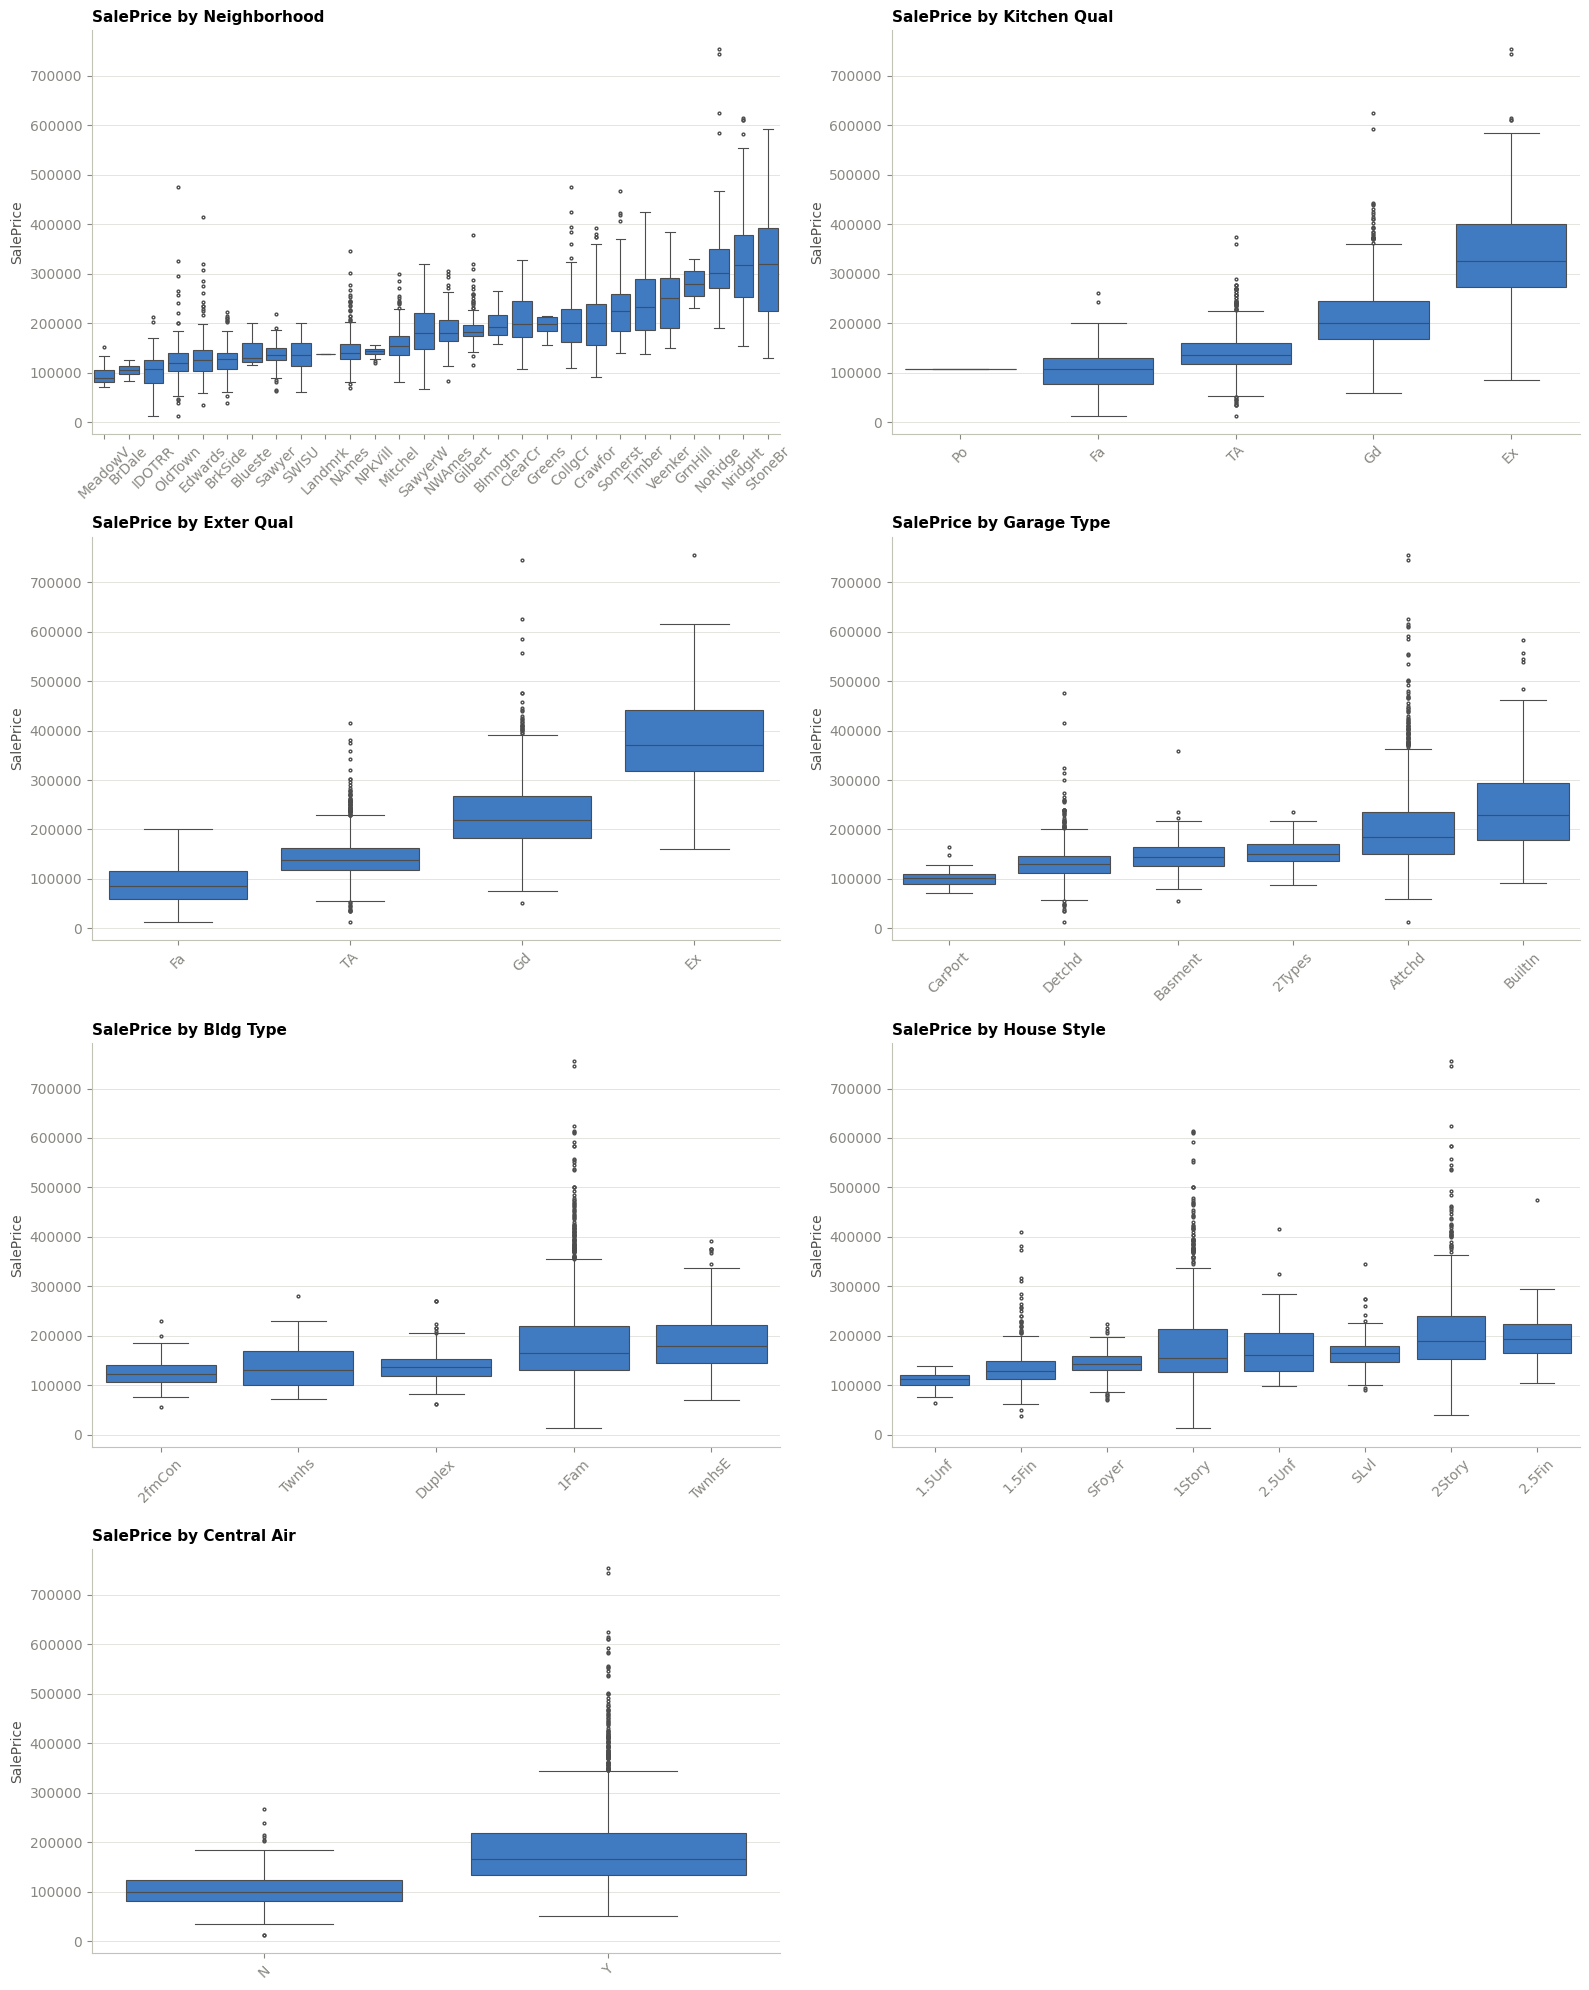

In [9]:
# --- Categorical Feature Analysis: SalePrice by category ---

cat_features = ['Neighborhood', 'Kitchen Qual', 'Exter Qual', 'Garage Type',
                 'Bldg Type', 'House Style', 'Central Air']

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    order = df.groupby(col)['SalePrice'].median().sort_values().index
    sns.boxplot(data=df, x=col, y='SalePrice', order=order, ax=axes[i],
                color=BLUE, fliersize=2, linewidth=0.8)
    axes[i].set_title(f'SalePrice by {col}', fontsize=11, fontweight='bold', loc='left')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')
    for spine in ['top', 'right']:
        axes[i].spines[spine].set_visible(False)

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

## 2.5 Correlation Analysis

Top 15 features correlated with SalePrice:
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Mas Vnr Area      0.508285
TotRms AbvGrd     0.495474
Fireplaces        0.474558
BsmtFin SF 1      0.432914
Lot Frontage      0.357318
Name: SalePrice, dtype: float64


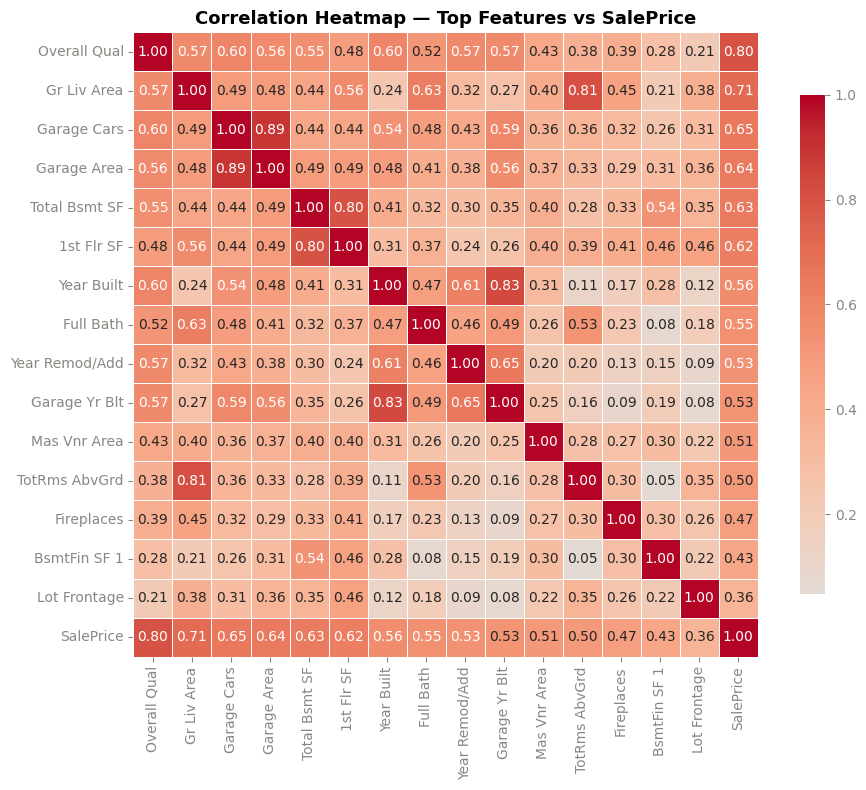

In [10]:
# --- Correlation Analysis: numeric features vs SalePrice ---

# Correlation matrix (Pearson) for all numeric columns
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# Top features most correlated with SalePrice (absolute value, excluding SalePrice itself)
sp_corr = corr_matrix['SalePrice'].drop('SalePrice').sort_values(key=abs, ascending=False)
print("Top 15 features correlated with SalePrice:")
print(sp_corr.head(15))

# --- Heatmap of top correlated features ---
top_features = sp_corr.head(15).index.tolist() + ['SalePrice']
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Top Features vs SalePrice', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Automated EDA (ydata-profiling) 

In [11]:
# --- Automated EDA with ydata-profiling ---
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Ames Housing — Automated EDA Report", explorative=True)
profile.to_file("ames_eda_report.html")
print("Report saved: ames_eda_report.html")

C:\Users\Hello\AppData\Local\Temp\ipykernel_24472\1955711083.py:2: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 82/82 [00:00<00:00, 183.34it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Report saved: ames_eda_report.html


# 4. Data Preprocessing

## 4.1 Handle Duplicates

In [12]:
# Full-row duplicates
print("Full duplicate rows:", df.duplicated().sum())

print("Duplicate PIDs:", df['PID'].duplicated().sum())

if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print("Duplicates dropped. New shape:", df.shape)
else:
    print("No duplicates found — nothing to drop.")

Full duplicate rows: 0
Duplicate PIDs: 0
No duplicates found — nothing to drop.


## 4.2 Train / Validation / Test Split

In [13]:
# --- 4.2 Train / Validation / Test Split ---
# Moved up (before Missing Values, Feature Engineering, etc.) so every statistic
# used later in preprocessing (medians, modes, rare-category thresholds) is
# learned ONLY from training data, never from val/test -- avoids leakage.

# Step 1: carve off the test set (20%) -- untouched until final evaluation
train_val_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Step 2: split the remaining 80% into train (60% of total) and validation (20% of total)
train_df, val_df = train_test_split(train_val_df, test_size=0.25, random_state=42)

print(f"Train: {train_df.shape[0]} rows ({train_df.shape[0] / len(df):.1%})")
print(f"Val:   {val_df.shape[0]} rows ({val_df.shape[0] / len(df):.1%})")
print(f"Test:  {test_df.shape[0]} rows ({test_df.shape[0] / len(df):.1%})")

Train: 1758 rows (60.0%)
Val:   586 rows (20.0%)
Test:  586 rows (20.0%)


In [14]:
df.shape
#
# df.info()
df.describe()


,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


## 4.3 Handle Missing Values

In [15]:
# --- 4.3 Handle Missing Values ---
print("Missing values before (train):", train_df.isnull().sum().sum())

none_cat_cols = ['Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Fireplace Qu',
                  'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond',
                  'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2']

zero_num_cols = ['Garage Yr Blt', 'Garage Cars', 'Garage Area',
                  'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
                  'Bsmt Full Bath', 'Bsmt Half Bath', 'Mas Vnr Area']

# --- Learn statistics from TRAINING DATA ONLY ---
lot_frontage_by_neighborhood = train_df.groupby('Neighborhood')['Lot Frontage'].median()
lot_frontage_global_median = train_df['Lot Frontage'].median()
mas_vnr_mode = train_df.loc[train_df['Mas Vnr Type'].notnull(), 'Mas Vnr Type'].mode()[0]
electrical_mode = train_df['Electrical'].mode()[0]

def handle_missing_values(data):
    data = data.copy()
    data[none_cat_cols] = data[none_cat_cols].fillna('NA')
    data[zero_num_cols] = data[zero_num_cols].fillna(0)

    # Lot Frontage: fill using TRAIN-learned per-neighborhood median
    data['Lot Frontage'] = data['Lot Frontage'].fillna(data['Neighborhood'].map(lot_frontage_by_neighborhood))
    # Fallback for a neighborhood not seen in training, or still missing
    data['Lot Frontage'] = data['Lot Frontage'].fillna(lot_frontage_global_median)

    # Mas Vnr Type: has veneer (Area > 0) but Type missing -> TRAIN-learned mode
    mask_has_veneer_no_type = data['Mas Vnr Type'].isnull() & (data['Mas Vnr Area'] > 0)
    data.loc[mask_has_veneer_no_type, 'Mas Vnr Type'] = mas_vnr_mode
    data['Mas Vnr Type'] = data['Mas Vnr Type'].fillna('None')

    # Electrical: fill with TRAIN-learned mode
    data['Electrical'] = data['Electrical'].fillna(electrical_mode)
    return data

train_df = handle_missing_values(train_df)
val_df = handle_missing_values(val_df)
test_df = handle_missing_values(test_df)

print("Missing values after (train):", train_df.isnull().sum().sum())
print("Missing values after (val):  ", val_df.isnull().sum().sum())
print("Missing values after (test): ", test_df.isnull().sum().sum())

Missing values before (train): 9417
Missing values after (train): 0
Missing values after (val):   0
Missing values after (test):  0


## 4.4 Feature Engineering

In [16]:
# --- 4.4 Feature Engineering ---
def engineer_features(data):
    data = data.copy()
    data['House Age'] = data['Yr Sold'] - data['Year Built']
    data['Years Since Remodel'] = data['Yr Sold'] - data['Year Remod/Add']
    data['Total SF'] = data['Total Bsmt SF'] + data['1st Flr SF'] + data['2nd Flr SF']
    data['Total Bathrooms'] = (data['Full Bath'] + 0.5*data['Half Bath'] +
                                data['Bsmt Full Bath'] + 0.5*data['Bsmt Half Bath'])
    data['Total Porch SF'] = (data['Wood Deck SF'] + data['Open Porch SF'] +
                                data['Enclosed Porch'] + data['3Ssn Porch'] + data['Screen Porch'])
    data['Has Pool'] = (data['Pool Area'] > 0).astype(int)
    data['Has Garage'] = (data['Garage Area'] > 0).astype(int)
    data['Has Fireplace'] = (data['Fireplaces'] > 0).astype(int)
    data['Has 2nd Floor'] = (data['2nd Flr SF'] > 0).astype(int)
    data['Is Remodeled'] = (data['Year Remod/Add'] != data['Year Built']).astype(int)
    data['Is New House'] = (data['Yr Sold'] == data['Year Built']).astype(int)
    return data

train_df = engineer_features(train_df)
val_df = engineer_features(val_df)
test_df = engineer_features(test_df)

new_feats = ['House Age', 'Years Since Remodel', 'Total SF', 'Total Bathrooms',
             'Total Porch SF', 'Has Pool', 'Has Garage', 'Has Fireplace',
             'Has 2nd Floor', 'Is Remodeled', 'Is New House']
print('New features created:', new_feats)
print('New train shape:', train_df.shape)

print('\nCorrelation of new numeric features with SalePrice (train only):')
num_new_feats = ['House Age', 'Years Since Remodel', 'Total SF', 'Total Bathrooms', 'Total Porch SF']
print(train_df[num_new_feats + ['SalePrice']].corr()['SalePrice'].drop('SalePrice').sort_values(key=abs, ascending=False))

New features created: ['House Age', 'Years Since Remodel', 'Total SF', 'Total Bathrooms', 'Total Porch SF', 'Has Pool', 'Has Garage', 'Has Fireplace', 'Has 2nd Floor', 'Is Remodeled', 'Is New House']
New train shape: (1758, 93)

Correlation of new numeric features with SalePrice (train only):
Total SF               0.762682
Total Bathrooms        0.633352
House Age             -0.544263
Years Since Remodel   -0.518670
Total Porch SF         0.395643
Name: SalePrice, dtype: float64


## 4.5 Feature Selection

In [17]:
# --- 4.5 Feature Selection ---
print('Garage Cars vs Garage Area correlation (train):', train_df['Garage Cars'].corr(train_df['Garage Area']))
print('Garage Cars vs SalePrice (train):', train_df['Garage Cars'].corr(train_df['SalePrice']))
print('Garage Area vs SalePrice (train):', train_df['Garage Area'].corr(train_df['SalePrice']))

train_df = train_df.drop(columns=['Garage Area'])
val_df = val_df.drop(columns=['Garage Area'])
test_df = test_df.drop(columns=['Garage Area'])

print('\nShape after feature selection (train):', train_df.shape)
print('Shape after feature selection (val):', val_df.shape)
print('Shape after feature selection (test):', test_df.shape)

Garage Cars vs Garage Area correlation (train): 0.8858612565393014
Garage Cars vs SalePrice (train): 0.6376976695192514
Garage Area vs SalePrice (train): 0.6295931365628259

Shape after feature selection (train): (1758, 92)
Shape after feature selection (val): (586, 92)
Shape after feature selection (test): (586, 92)


## 4.6 Separate Numerical / Nominal / Ordinal Features

In [18]:
# --- 4.6 Separate Numerical / Nominal / Ordinal Features ---
target_col = 'SalePrice'
id_cols = ['Order', 'PID']

ordinal_cols = ['Lot Shape', 'Land Slope', 'Utilities', 'Exter Qual', 'Exter Cond',
                 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2',
                 'Heating QC', 'Electrical', 'Kitchen Qual', 'Functional', 'Fireplace Qu',
                 'Garage Finish', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence']

nominal_cols = ['MS Zoning', 'Street', 'Alley', 'Land Contour', 'Lot Config', 'Neighborhood',
                 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
                 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Foundation', 'Heating',
                 'Central Air', 'Garage Type', 'Misc Feature', 'Sale Type', 'Sale Condition']

numerical_cols = [c for c in train_df.select_dtypes(include=[np.number]).columns
                   if c not in id_cols + [target_col]]

print(f"Numerical features: {len(numerical_cols)}")
print(f"Nominal categorical features: {len(nominal_cols)}")
print(f"Ordinal categorical features: {len(ordinal_cols)}")
print(f"Total: {len(numerical_cols) + len(nominal_cols) + len(ordinal_cols)}")

all_classified = set(numerical_cols + nominal_cols + ordinal_cols + id_cols + [target_col])
missing = set(train_df.columns) - all_classified
print(f"\nUnclassified columns (should be empty set): {missing}")

# Binary flag columns (0/1) don't need power-transforming or scaling -- pass them through as-is.
# Garage Yr Blt is a year value, not a magnitude, so it's excluded from the transform too.
binary_flags = ['Has Pool', 'Has Garage', 'Has Fireplace', 'Has 2nd Floor',
                 'Is Remodeled', 'Is New House', 'Garage Yr Blt']
continuous_numerical_cols = [c for c in numerical_cols if c not in binary_flags]

Numerical features: 46
Nominal categorical features: 22
Ordinal categorical features: 21
Total: 89

Unclassified columns (should be empty set): set()


## 4.7 Encoding & Scaling

In [19]:
# ============================================================
# 4.7 Encoding & Scaling
# ============================================================

# --- 4.7a: Reduce cardinality by grouping rare categories into "Other" ---
# Learn which categories are rare using TRAINING DATA ONLY
rare_category_map = {}
for col in nominal_cols:
    counts = train_df[col].value_counts()
    rare_category_map[col] = counts[counts < 30].index

def apply_rare_grouping(data, rare_map):
    data = data.copy()
    for col, rare_categories in rare_map.items():
        data[col] = data[col].replace(rare_categories, 'Other')
    return data

train_df = apply_rare_grouping(train_df, rare_category_map)
val_df = apply_rare_grouping(val_df, rare_category_map)
test_df = apply_rare_grouping(test_df, rare_category_map)

total_after = sum(train_df[col].nunique() for col in nominal_cols)
print(f"Total OHE columns after grouping (train): {total_after}")

# --- 4.7b: Define (not fit yet) encoders for the pipeline ---
# Yeo-Johnson power transform + scaling for numerical features happens INSIDE
# the pipeline in Section 5 (fit only on X_train there, avoiding leakage).
ordinal_categories = [
    ['IR3', 'IR2', 'IR1', 'Reg'], ['Sev', 'Mod', 'Gtl'], ['ELO', 'NoSeWa', 'NoSewr', 'AllPub'],
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'], ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex'], ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    ['NA', 'No', 'Mn', 'Av', 'Gd'],
    ['NA', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'], ['NA', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'], ['Mix', 'FuseP', 'FuseF', 'FuseA', 'SBrkr'],
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'], ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ'],
    ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex'], ['NA', 'Unf', 'RFn', 'Fin'],
    ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex'], ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    ['N', 'P', 'Y'], ['NA', 'Fa', 'TA', 'Gd', 'Ex'], ['NA', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv'],
]

print("\nEncoders will be defined and fit inside the ColumnTransformer in Section 5.")

# --- Assemble final X / y sets for modeling ---
feature_cols = numerical_cols + nominal_cols + ordinal_cols
X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_val = val_df[feature_cols]
y_val = val_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

print(f"\nTrain: {X_train.shape[0]} rows, {X_train.shape[1]} features")
print(f"Val:   {X_val.shape[0]} rows, {X_val.shape[1]} features")
print(f"Test:  {X_test.shape[0]} rows, {X_test.shape[1]} features")

Total OHE columns after grouping (train): 105

Encoders will be defined and fit inside the ColumnTransformer in Section 5.

Train: 1758 rows, 89 features
Val:   586 rows, 89 features
Test:  586 rows, 89 features


# 5. Pipelines & ColumnTransformer 

In [20]:
# --- 5. Pipelines & ColumnTransformer ---

# Continuous numerical features: Yeo-Johnson power transform (fixes skew) + standardizes in one step
numerical_pipeline = Pipeline([
    ('power', PowerTransformer(method='yeo-johnson', standardize=True))
])

# Nominal features: one-hot encode
nominal_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Ordinal features: encode using the worst->best category orders defined in 4.7b
ordinal_pipeline = Pipeline([
    ('encoder', OrdinalEncoder(categories=ordinal_categories,
                                handle_unknown='use_encoded_value',
                                unknown_value=-1))
])

# Binary flags (already 0/1) -- passed through untouched, no transform needed
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, continuous_numerical_cols),
    ('bin', 'passthrough', binary_flags),
    ('nom', nominal_pipeline, nominal_cols),
    ('ord', ordinal_pipeline, ordinal_cols)
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

# 6. Model Development 

## 6.1 SVR (GridSearchCV)

In [21]:
# --- 6.1 Model Development: SVR (GridSearchCV) ---
from sklearn.svm import SVR
from sklearn.base import clone

svr_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', SVR())
])

param_grid_svr = {
    'model__kernel': ['linear'],
    'model__C': [2000, 5000, 8000, 10000],
    'model__epsilon': [0.0005, 0.001, 0.002, 0.005]
}
svr_grid_search = GridSearchCV(
    svr_pipeline,
    param_grid=param_grid_svr,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

svr_grid_search.fit(X_train, y_train)

print("Best parameters:", svr_grid_search.best_params_)
print("Best CV RMSE:", np.sqrt(-svr_grid_search.best_score_))

best_svr = svr_grid_search.best_estimator_

y_train_pred = best_svr.predict(X_train)
print("Training R²:", r2_score(y_train, y_train_pred))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters: {'model__C': 5000, 'model__epsilon': 0.005, 'model__kernel': 'linear'}
Best CV RMSE: 31989.209059212542
Training R²: 0.8534934328344342


### 6.1 SVR Visual


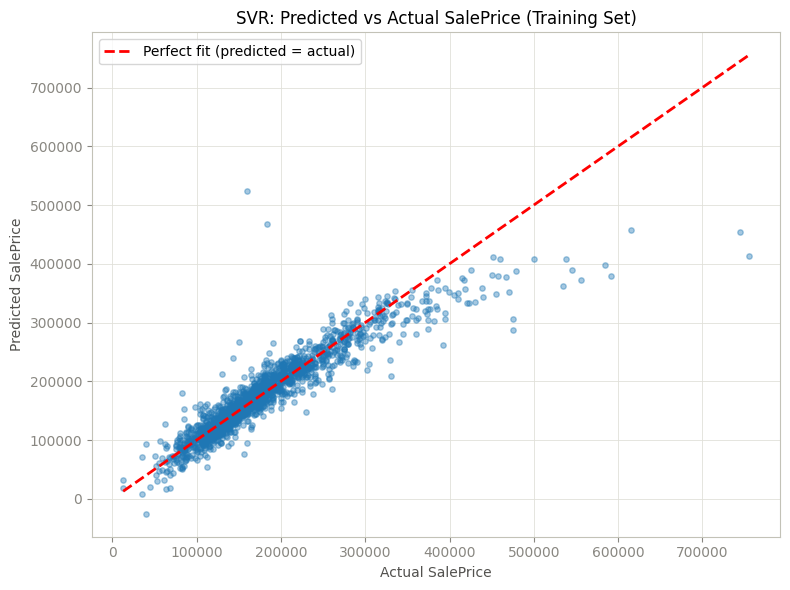

In [22]:
# --- 6.1 Visual: SVR Predicted vs Actual (Training Set) ---
y_train_pred = best_svr.predict(X_train)

plt.figure(figsize=(8, 6))
plt.scatter(y_train, y_train_pred, alpha=0.4, s=15)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()],
         'r--', linewidth=2, label='Perfect fit (predicted = actual)')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('SVR: Predicted vs Actual SalePrice (Training Set)')
plt.legend()
plt.tight_layout()
plt.show()

## 6.2 Linear Regression

In [23]:
from sklearn.base import clone
from sklearn.linear_model import LinearRegression
from sklearn.compose import TransformedTargetRegressor

log_linear_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', LinearRegression())
])

log_linear_model = TransformedTargetRegressor(
    regressor=log_linear_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

log_linear_model.fit(X_train, y_train)

log_linear_val_pred = log_linear_model.predict(X_val)

log_linear_mae = mean_absolute_error(y_val, log_linear_val_pred)
log_linear_rmse = np.sqrt(mean_squared_error(y_val, log_linear_val_pred))
log_linear_r2 = r2_score(y_val, log_linear_val_pred)

print(f"Validation MAE:  ${log_linear_mae:,.2f}")
print(f"Validation RMSE: ${log_linear_rmse:,.2f}")
print(f"Validation R²:   {log_linear_r2:.4f}")

Validation MAE:  $14,178.32
Validation RMSE: $20,193.10
Validation R²:   0.9257


In [24]:
from sklearn.linear_model import Ridge, Lasso

# Baseline Linear Regression
linear_search = GridSearchCV(
    Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('model', LinearRegression())
    ]),
    param_grid={},
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
linear_search.fit(X_train, y_train)

# Ridge Regression
ridge_search = GridSearchCV(
    Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('model', Ridge())
    ]),
    param_grid={'model__alpha': [0.1, 1, 10, 30, 100, 300]},
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
ridge_search.fit(X_train, y_train)

# Lasso Regression
lasso_search = GridSearchCV(
    Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('model', Lasso(max_iter=10000))
    ]),
    param_grid={'model__alpha': [0.0001, 0.001, 0.01, 0.1]},
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
lasso_search.fit(X_train, y_train)

results = {
    'LinearRegression': linear_search,
    'Ridge': ridge_search,
    'Lasso': lasso_search
}

for name, search in results.items():
    print(f"\n{name}")
    print("Best parameters:", search.best_params_)
    print("Best CV RMSE:", np.sqrt(-search.best_score_))

best_name = min(results, key=lambda name: -results[name].best_score_)
best_linear = results[best_name].best_estimator_

print(f"\nSelected model: {best_name}")

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits

LinearRegression
Best parameters: {}
Best CV RMSE: 35836.58921630879

Ridge
Best parameters: {'model__alpha': 100}
Best CV RMSE: 33336.12885182432

Lasso
Best parameters: {'model__alpha': 0.1}
Best CV RMSE: 35806.497859746

Selected model: Ridge


c:\Users\Hello\Desktop\NTI\Assigments\Assigment 4\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.324739e+11, tolerance: 1.072e+09
  model = cd_fast.enet_coordinate_descent(


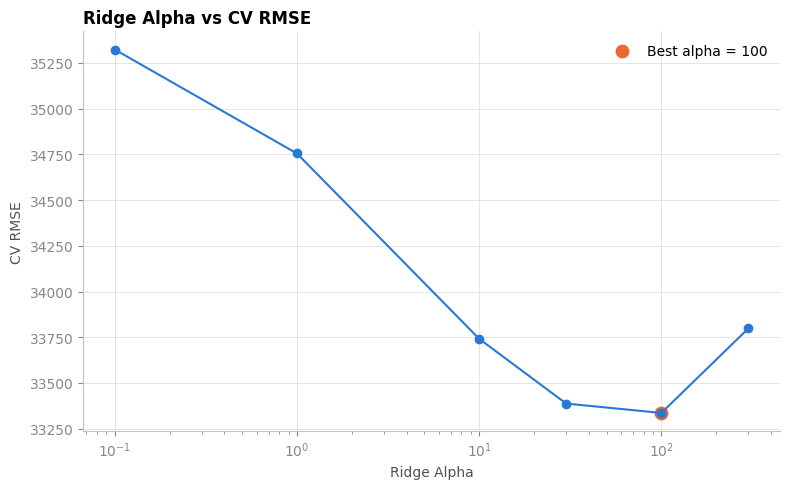

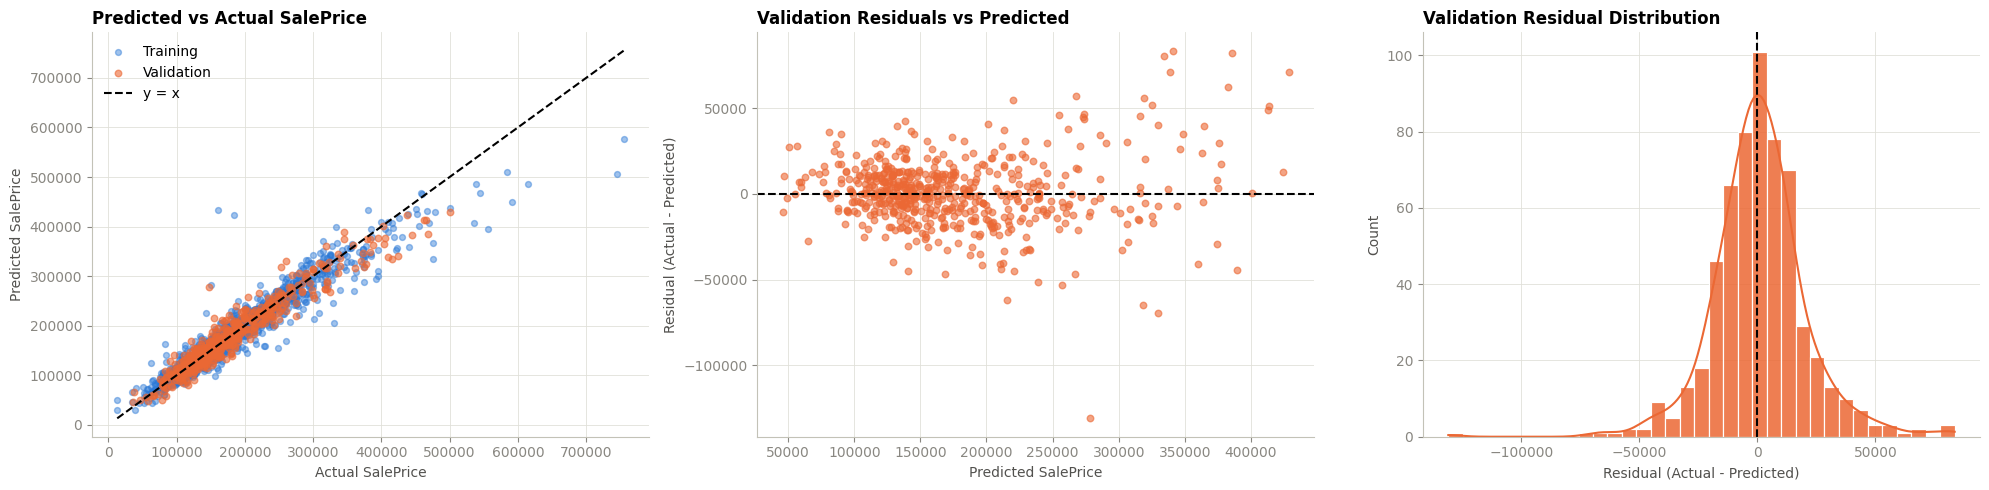

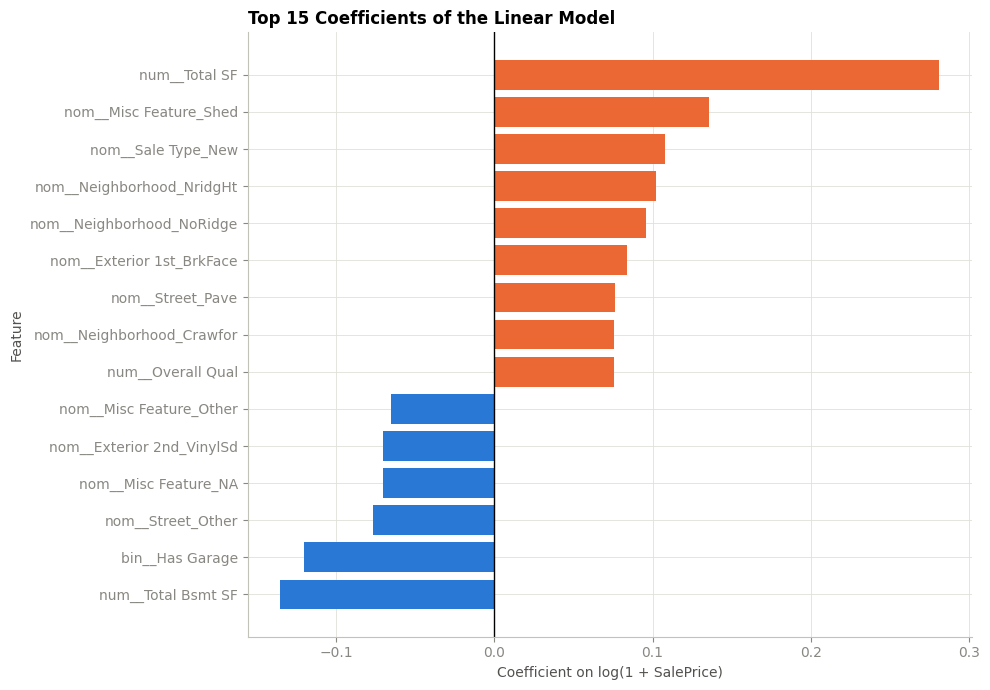

In [25]:
# Use the log-target linear model so coefficients are on the log-price scale.
linear_model = log_linear_model
fitted_pipeline = linear_model.regressor_
fitted_preprocessor = fitted_pipeline.named_steps['preprocessor']

# Predictions and residuals
train_pred = linear_model.predict(X_train)
val_pred = linear_model.predict(X_val)
val_residuals = y_val - val_pred

# --- 1. Ridge alpha vs CV RMSE ---
ridge_results = pd.DataFrame(ridge_search.cv_results_)
ridge_results = ridge_results.sort_values('param_model__alpha')

plt.figure(figsize=(8, 5))
plt.plot(
    ridge_results['param_model__alpha'],
    np.sqrt(-ridge_results['mean_test_score']),
    marker='o',
    color=BLUE
)
best_alpha = ridge_search.best_params_['model__alpha']
best_ridge_rmse = np.sqrt(-ridge_search.best_score_)
plt.scatter(best_alpha, best_ridge_rmse, color=ORANGE, s=80,
            label=f'Best alpha = {best_alpha}')
plt.xscale('log')
plt.xlabel('Ridge Alpha')
plt.ylabel('CV RMSE')
plt.title('Ridge Alpha vs CV RMSE', fontweight='bold', loc='left')
plt.legend(frameon=False)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


# --- 2–4. Prediction and residual diagnostics ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Predicted vs Actual
axes[0].scatter(y_train, train_pred, color=BLUE, alpha=0.45,
                s=18, label='Training')
axes[0].scatter(y_val, val_pred, color=ORANGE, alpha=0.6,
                s=22, label='Validation')

plot_min = min(y_train.min(), y_val.min(), train_pred.min(), val_pred.min())
plot_max = max(y_train.max(), y_val.max(), train_pred.max(), val_pred.max())
axes[0].plot([plot_min, plot_max], [plot_min, plot_max],
             'k--', linewidth=1.5, label='y = x')
axes[0].set_xlabel('Actual SalePrice')
axes[0].set_ylabel('Predicted SalePrice')
axes[0].set_title('Predicted vs Actual SalePrice',
                  fontweight='bold', loc='left')
axes[0].legend(frameon=False)

# Residuals vs Predicted
axes[1].scatter(val_pred, val_residuals, color=ORANGE,
                alpha=0.6, s=22)
axes[1].axhline(0, color='k', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted SalePrice')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Validation Residuals vs Predicted',
                  fontweight='bold', loc='left')

# Residual histogram
sns.histplot(val_residuals, bins=35, kde=True, color=ORANGE,
             edgecolor='white', alpha=0.85, ax=axes[2])
axes[2].axvline(0, color='k', linestyle='--', linewidth=1.5)
axes[2].set_xlabel('Residual (Actual - Predicted)')
axes[2].set_ylabel('Count')
axes[2].set_title('Validation Residual Distribution',
                  fontweight='bold', loc='left')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


# --- 5. Top 15 coefficients ---
feature_names = fitted_preprocessor.get_feature_names_out()
coefficients = fitted_pipeline.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})
coef_df['Absolute Coefficient'] = coef_df['Coefficient'].abs()

top_coefficients = (
    coef_df.sort_values('Absolute Coefficient', ascending=False)
           .head(15)
           .sort_values('Coefficient')
)

plt.figure(figsize=(10, 7))
colors = [
    BLUE if value < 0 else ORANGE
    for value in top_coefficients['Coefficient']
]

plt.barh(top_coefficients['Feature'],
         top_coefficients['Coefficient'],
         color=colors)
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Coefficient on log(1 + SalePrice)')
plt.ylabel('Feature')
plt.title('Top 15 Coefficients of the Linear Model',
          fontweight='bold', loc='left')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 6.3 KNN (GridSearchCV)

In [26]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.base import clone

In [27]:
# --- 6.3 KNN Regression ---

knn_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', KNeighborsRegressor())
])
param_grid_knn = {
    'model__n_neighbors': [3, 5, 7, 9, 11],
    'model__weights': ['uniform', 'distance'],
    'model__p': [1, 2]
}

In [28]:
knn_grid_search = GridSearchCV(
    knn_pipeline,
    param_grid=param_grid_knn,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

In [29]:
knn_grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__n_neighbors': [3, 5, ...], 'model__p': [1, 2], 'model__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_mo

In [30]:
print("Best parameters:", knn_grid_search.best_params_)
print("Best CV RMSE:", np.sqrt(-knn_grid_search.best_score_))

Best parameters: {'model__n_neighbors': 9, 'model__p': 1, 'model__weights': 'distance'}
Best CV RMSE: 34508.44911788637


In [31]:
best_knn = knn_grid_search.best_estimator_

In [32]:
best_knn

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](89,)","['MS SubClass','Lot Frontage','Lot Area',...,'Paved Drive','Pool QC', 'Fence']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,89
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subse

In [33]:
knn_train_pred = best_knn.predict(X_train)
knn_val_pred = best_knn.predict(X_val)

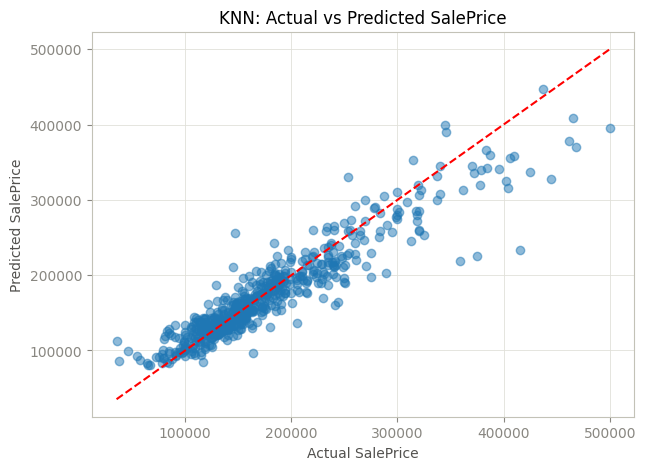

In [34]:
plt.figure(figsize=(7, 5))

plt.scatter(y_val, knn_val_pred, alpha=0.5)

plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    'r--'
)

plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('KNN: Actual vs Predicted SalePrice')

plt.show()

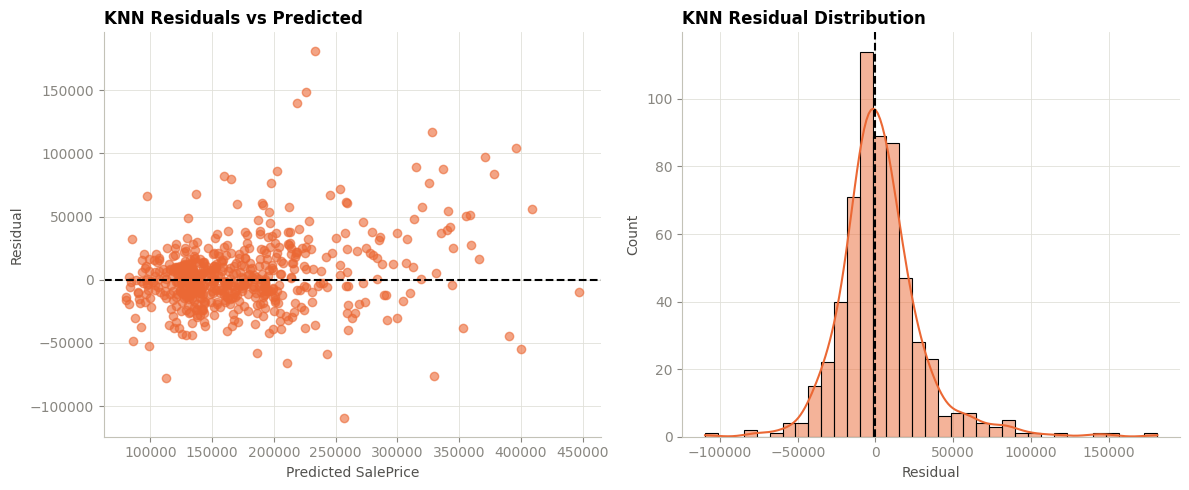

In [35]:
# --- 6.3 KNN Residual Diagnostics ---

knn_val_pred = best_knn.predict(X_val)
knn_residuals = y_val - knn_val_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(knn_val_pred, knn_residuals, color=ORANGE, alpha=0.6)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_xlabel('Predicted SalePrice')
axes[0].set_ylabel('Residual')
axes[0].set_title('KNN Residuals vs Predicted',
                  fontweight='bold', loc='left')

sns.histplot(
    knn_residuals,
    bins=35,
    kde=True,
    color=ORANGE,
    ax=axes[1]
)

axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Residual')
axes[1].set_title('KNN Residual Distribution',
                  fontweight='bold', loc='left')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# 7. Evaluation & Comparison 

In [36]:
# --- 7. Evaluation & Comparison ---

def get_metrics(model, X, y):
    pred = model.predict(X)
    mse = mean_squared_error(y, pred)

    return {
        'MAE': mean_absolute_error(y, pred),
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'R2': r2_score(y, pred)
    }

In [37]:
models = {
    'SVR': best_svr,
    'Linear Regression': best_linear,
    'KNN': best_knn
}

comparison_results = []

for name, model in models.items():

    train_metrics = get_metrics(model, X_train, y_train)
    val_metrics = get_metrics(model, X_val, y_val)

    comparison_results.append({
        'Model': name,

        'Train MAE': train_metrics['MAE'],
        'Train MSE': train_metrics['MSE'],
        'Train RMSE': train_metrics['RMSE'],
        'Train R2': train_metrics['R2'],

        'Validation MAE': val_metrics['MAE'],
        'Validation MSE': val_metrics['MSE'],
        'Validation RMSE': val_metrics['RMSE'],
        'Validation R2': val_metrics['R2'],

        'RMSE Gap': val_metrics['RMSE'] - train_metrics['RMSE']
    })

comparison_df = pd.DataFrame(comparison_results)

comparison_df

,Model,Train MAE,Train MSE,Train RMSE,Train R2,Validation MAE,Validation MSE,Validation RMSE,Validation R2,RMSE Gap
0,SVR,17175.182932,8.934024e+08,29889.837341,0.853493,17351.979284,6.426141e+08,25349.833522,0.882843,-4540.003819
1,Linear Regression,17975.489941,8.591490e+08,29311.244351,0.859111,17576.746257,6.155405e+08,24810.089478,0.887779,-4501.154873
2,KNN,0.000000,0.000000e+00,0.000000,1.000000,18500.576521,7.594130e+08,27557.449389,0.861550,27557.449389


In [38]:
comparison_df.style.format({
    'Train MAE': '{:,.2f}',
    'Train MSE': '{:,.2f}',
    'Train RMSE': '{:,.2f}',
    'Train R2': '{:.4f}',
    'Validation MAE': '{:,.2f}',
    'Validation MSE': '{:,.2f}',
    'Validation RMSE': '{:,.2f}',
    'Validation R2': '{:.4f}',
    'RMSE Gap': '{:,.2f}'
})

,Model,Train MAE,Train MSE,Train RMSE,Train R2,Validation MAE,Validation MSE,Validation RMSE,Validation R2,RMSE Gap
0,SVR,"17,175.18","893,402,376.29","29,889.84",0.8535,"17,351.98","642,614,059.61","25,349.83",0.8828,"-4,540.00"
1,Linear Regression,"17,975.49","859,149,045.41","29,311.24",0.8591,"17,576.75","615,540,539.90","24,810.09",0.8878,"-4,501.15"
2,KNN,0.00,0.00,0.00,1.0000,"18,500.58","759,413,016.85","27,557.45",0.8615,"27,557.45"


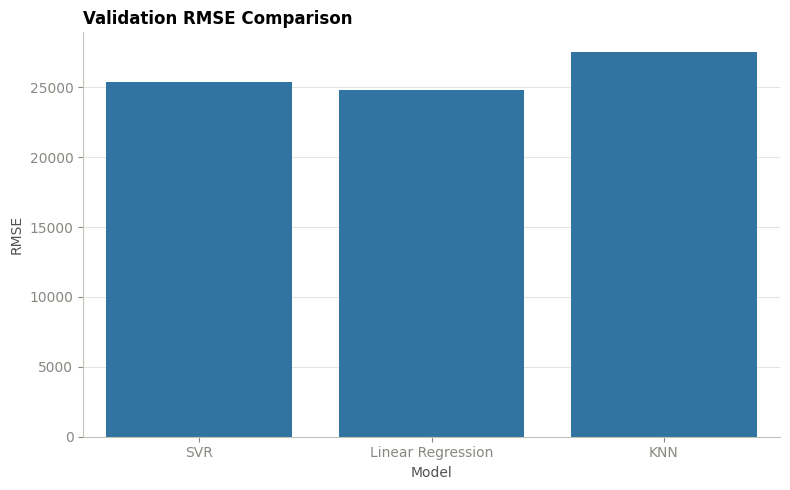

In [39]:
# --- Validation RMSE Comparison ---

plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison_df,
    x='Model',
    y='Validation RMSE'
)

plt.title(
    'Validation RMSE Comparison',
    fontweight='bold',
    loc='left'
)

plt.xlabel('Model')
plt.ylabel('RMSE')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

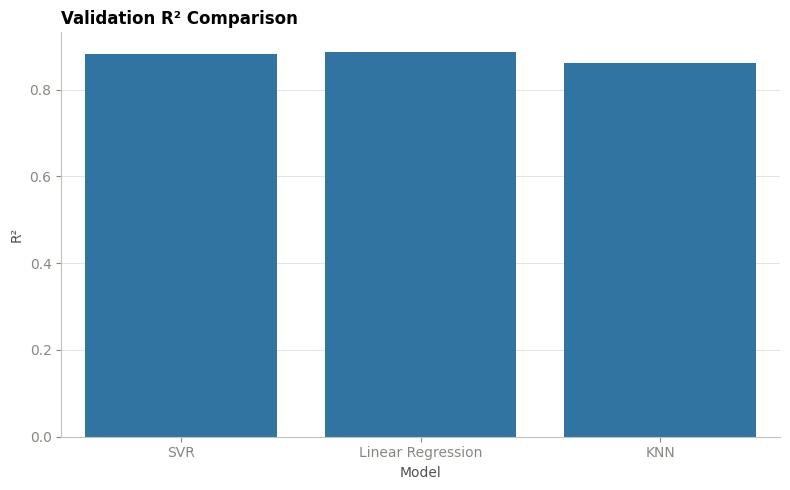

In [40]:
# --- Validation R² Comparison ---

plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison_df,
    x='Model',
    y='Validation R2'
)

plt.title(
    'Validation R² Comparison',
    fontweight='bold',
    loc='left'
)

plt.xlabel('Model')
plt.ylabel('R²')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

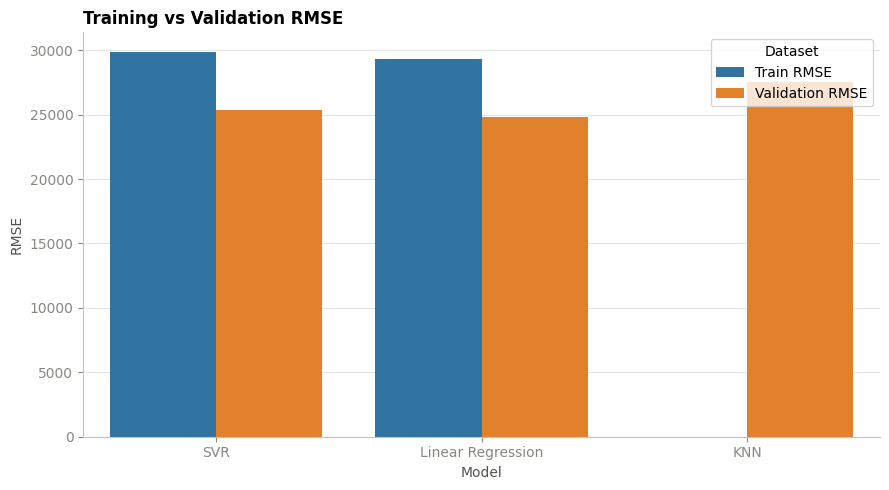

In [41]:
# --- Training vs Validation RMSE ---

rmse_df = comparison_df[
    ['Model', 'Train RMSE', 'Validation RMSE']
].melt(
    id_vars='Model',
    var_name='Dataset',
    value_name='RMSE'
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=rmse_df,
    x='Model',
    y='RMSE',
    hue='Dataset'
)

plt.title(
    'Training vs Validation RMSE',
    fontweight='bold',
    loc='left'
)

plt.xlabel('Model')
plt.ylabel('RMSE')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [42]:
comparison_df[
    ['Model', 'Validation RMSE', 'Validation R2', 'RMSE Gap']
].sort_values('Validation RMSE')

,Model,Validation RMSE,Validation R2,RMSE Gap
1,Linear Regression,24810.089478,0.887779,-4501.154873
0,SVR,25349.833522,0.882843,-4540.003819
2,KNN,27557.449389,0.861550,27557.449389


In [43]:
best_model_name = comparison_df.loc[
    comparison_df['Validation RMSE'].idxmin(),
    'Model'
]

print("Best model based on Validation RMSE:", best_model_name)

Best model based on Validation RMSE: Linear Regression


In [44]:
# --- 7 (cont.): Final Test-Set Evaluation of the Winning Model ---
best_model = models[best_model_name]

val_metrics_best = get_metrics(best_model, X_val, y_val)
test_metrics_best = get_metrics(best_model, X_test, y_test)

final_eval_df = pd.DataFrame([
    {'Set': 'Validation', **val_metrics_best},
    {'Set': 'Test',       **test_metrics_best},
])

print(f"Winning model: {best_model_name}\n")
final_eval_df.style.format({'MAE': '{:,.2f}', 'MSE': '{:,.2f}', 'RMSE': '{:,.2f}', 'R2': '{:.4f}'})

Winning model: Linear Regression



,Set,MAE,MSE,RMSE,R2
0,Validation,"17,576.75","615,540,539.90","24,810.09",0.8878
1,Test,"20,421.75","1,120,819,481.51","33,478.64",0.8602


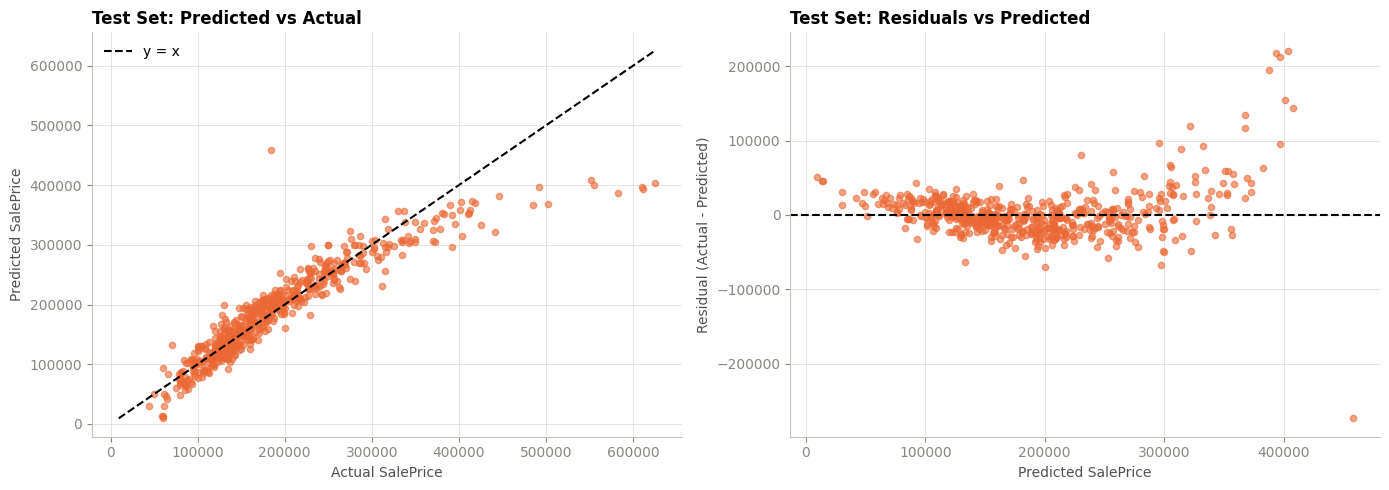

,Actual,Predicted,Abs Error
2181,"184,750","458,333","273,583"
2445,"625,000","404,058","220,942"
44,"611,657","393,987","217,670"
432,"610,000","397,040","212,960"
433,"582,933","387,543","195,390"
423,"555,000","400,931","154,069"
456,"552,000","408,324","143,676"
366,"501,837","368,022","133,815"
1641,"441,929","322,003","119,926"
422,"485,000","367,426","117,574"


: 

In [ ]:
# --- 7 (cont.): Test-Set Residual Diagnostics for the Winning Model ---
test_pred = best_model.predict(X_test)
test_residuals = y_test - test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_test, test_pred, color=ORANGE, alpha=0.6, s=20)
plot_min = min(y_test.min(), test_pred.min())
plot_max = max(y_test.max(), test_pred.max())
axes[0].plot([plot_min, plot_max], [plot_min, plot_max], 'k--', linewidth=1.5, label='y = x')
axes[0].set_xlabel('Actual SalePrice')
axes[0].set_ylabel('Predicted SalePrice')
axes[0].set_title('Test Set: Predicted vs Actual', fontweight='bold', loc='left')
axes[0].legend(frameon=False)

# Residuals vs Predicted
axes[1].scatter(test_pred, test_residuals, color=ORANGE, alpha=0.6, s=20)
axes[1].axhline(0, color='k', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted SalePrice')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Test Set: Residuals vs Predicted', fontweight='bold', loc='left')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# --- Top 10 worst-predicted test houses, by absolute error ---
worst_errors = pd.DataFrame({
    'Actual': y_test,
    'Predicted': test_pred,
    'Abs Error': (y_test - test_pred).abs()
}).sort_values('Abs Error', ascending=False).head(10)

worst_errors.style.format({'Actual': '{:,.0f}', 'Predicted': '{:,.0f}', 'Abs Error': '{:,.0f}'})